In [1]:
import os
import sys
import yaml
sys.path.append(os.path.abspath('../src'))
import matplotlib.cm as cm

from utils import *

# Load config (relative to notebooks/)
with open('../config.yml', 'r') as f:
    config = yaml.safe_load(f)

I0000 00:00:1776957510.066712   33755 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
train_dir = config['paths']['train_dir']
val_dir = config['paths']['val_dir']
test_dir = config['paths']['test_dir']

I0000 00:00:1776957515.260922   33755 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2244 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


Found 2012 files belonging to 23 classes.
Found 2012 files belonging to 23 classes.


I0000 00:00:1776957529.360059   33840 service.cc:153] XLA service 0x7f0064066dc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776957529.360102   33840 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1650, Compute Capability 7.5 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776957529.437532   33840 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776957530.009836   33840 cuda_dnn.cc:461] Loaded cuDNN version 92000


  1/126 ━━━━━━━━━━━━━━━━━━━━ 16:49 8s/step

I0000 00:00:1776957535.317400   33840 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step


W0000 00:00:1776957568.431207   33842 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.52GiB (rounded to 1635815936)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
I0000 00:00:1776957568.431434   33842 bfc_allocator.cc:1049] BFCAllocator dump for GPU_0_bfc
I0000 00:00:1776957568.431440   33842 bfc_allocator.cc:1056] Bin (256): 	Total Chunks: 286, Chunks in use: 286. 71.5KiB allocated for chunks. 71.5KiB in use in bin. 35.5KiB client-requested in use in bin.
I0000 00:00:1776957568.431446   33842 bfc_allocator.cc:1056] Bin (512): 	Total Chunks: 134, Chunks in use: 134. 80.5KiB allocated for chunks. 80.5KiB in use in bin. 74.5KiB client-requested in use in bin.
I0000 00:00:1776957568.431449   33842 bfc_allocator.cc:1056] Bin (1024): 	Total Chunks: 190, Chunks in use: 190. 194.5KiB al

125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step

E0000 00:00:1776957606.328802   33842 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1776957609.025149   33842 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1776957611.019689   33842 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


126/126 ━━━━━━━━━━━━━━━━━━━━ 68s 291ms/step
Found 1980 files belonging to 23 classes.
Found 1980 files belonging to 23 classes.
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step
124/124 ━━━━━━━━━━━━━━━━━━━━ 14s 113ms/step
Optimal Weight (Model 256): 0.55 | Optimal Weight (Model 300): 0.45
Validation Maximum Macro F1: 0.8320

  Ensemble Base (ResNet50 + EffNetV2S) - Test Evaluation
  Test Accuracy: 0.8549
  Test F1 Macro: 0.8399

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.95      0.94      0.95        87
      Boris_Kustodiev       0.85      0.60      0.70        67
     Camille_Pissarro       0.77      0.80      0.78        93
        Childe_Hassam       0.84      0.74      0.79        58
         Claude_Monet       0.95      0.81      0.87       141
          Edgar_Degas       0.91      0.78      0.84        65
        Eugene_Boudin       0.82      0.93      0.87        59
         Gustave_Dore       0.91      0.97    

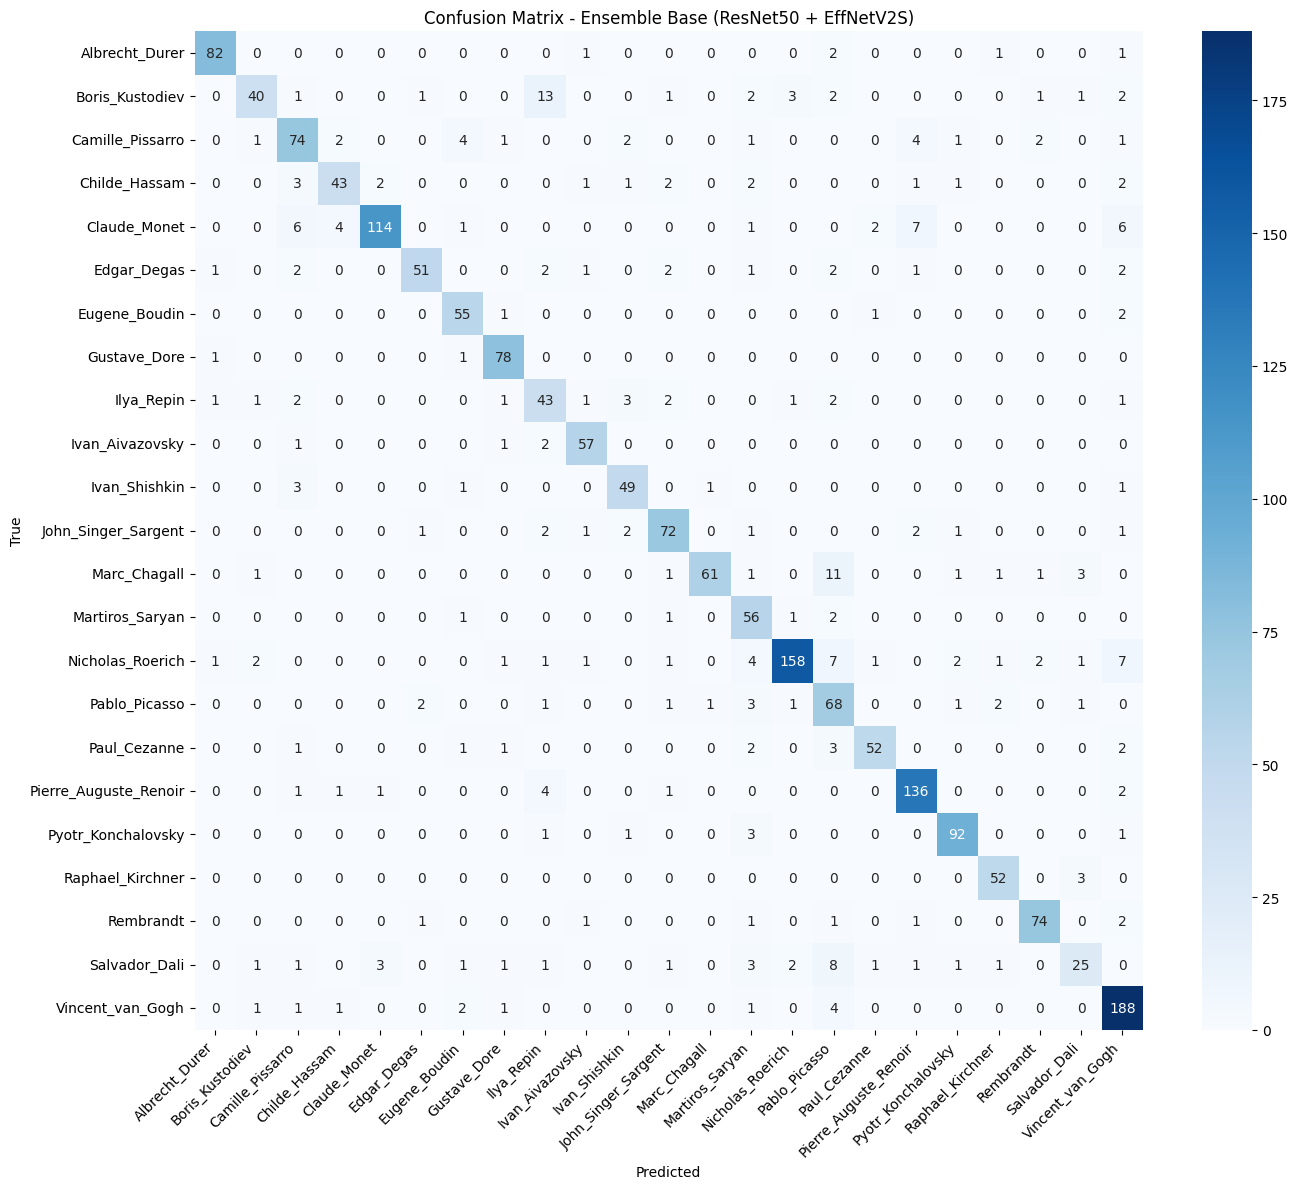

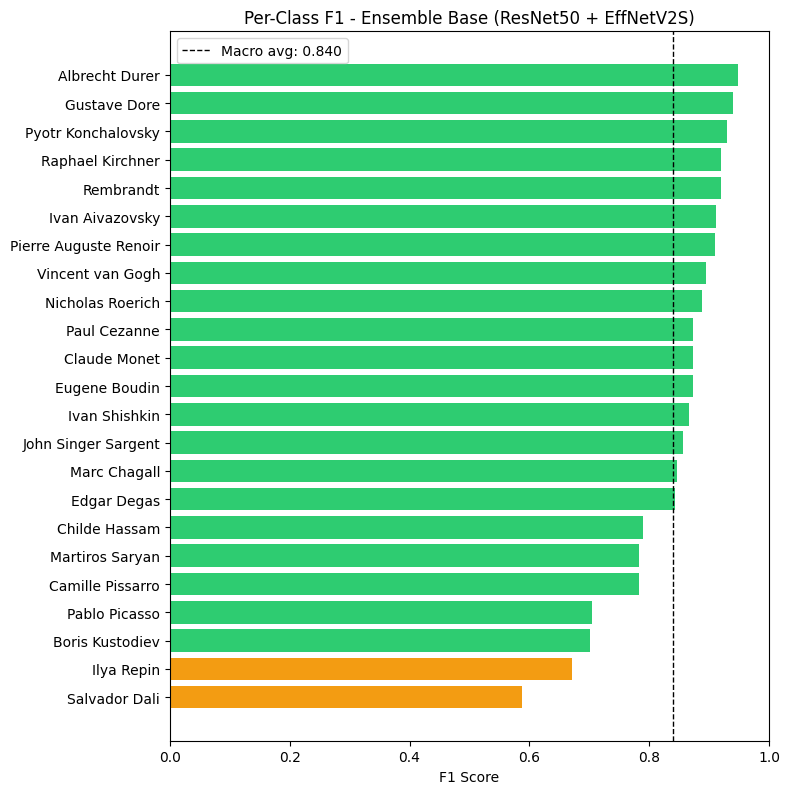

In [3]:
# ── 1. Load Pre-trained Models ────────────────────────────────────────────────
# Load the trained models. Note that each model expects a different 
# input spatial resolution (256x256 and 300x300).
model_256 = keras.saving.load_model("../models/resnet50/resnet50_v3_best.keras")
model_300 = keras.saving.load_model("../models/EfficientNetV2S/effnetv2s_v1_best.keras")

# ── 2. Prepare Test Datasets ──────────────────────────────────────────────────
test_ds_256 = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(256, 256),
    batch_size=16,
    shuffle=False,
    label_mode="int"
)

# Extract class names BEFORE applying .prefetch()
class_names = test_ds_256.class_names

# Apply prefetch for performance optimization
test_ds_256 = test_ds_256.prefetch(tf.data.AUTOTUNE)

test_ds_300 = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(300, 300),
    batch_size=16,
    shuffle=False,
    label_mode="int"
).prefetch(tf.data.AUTOTUNE)

# ── 3. Extract Test Probabilities ─────────────────────────────────────────────
probs_test_256 = model_256.predict(test_ds_256)
probs_test_300 = model_300.predict(test_ds_300)

# ── 4. Extract Ground Truth Labels ────────────────────────────────────────────
y_test_true = np.concatenate([y for _, y in test_ds_256], axis=0)

# ── 5. Prepare Validation Datasets ────────────────────────────────────────────
val_ds_256 = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(256, 256),
    batch_size=16,
    shuffle=False,
    label_mode="int"
).prefetch(tf.data.AUTOTUNE)

val_ds_300 = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(300, 300),
    batch_size=16,
    shuffle=False,
    label_mode="int"
).prefetch(tf.data.AUTOTUNE)

probs_val_256 = model_256.predict(val_ds_256)
probs_val_300 = model_300.predict(val_ds_300)
y_val_true    = np.concatenate([y for _, y in val_ds_256], axis=0)

# ── 6. Optimize Ensemble Weights via Grid Search ──────────────────────────────
best_f1, best_w = 0, 0
for w in np.arange(0.0, 1.05, 0.05):
    probs = w * probs_val_256 + (1 - w) * probs_val_300
    preds = np.argmax(probs, axis=1)
    f1 = f1_score(y_val_true, preds, average="macro")
    if f1 > best_f1:
        best_f1, best_w = f1, w

print(f"Optimal Weight (Model 256): {best_w:.2f} | Optimal Weight (Model 300): {1-best_w:.2f}")
print(f"Validation Maximum Macro F1: {best_f1:.4f}")

# ── 7. Evaluate Ensemble Performance on Test Set ──────────────────────────────
ensemble_probs_test = best_w * probs_test_256 + (1 - best_w) * probs_test_300
ensemble_preds_test = np.argmax(ensemble_probs_test, axis=1)

metrics_ensemble = evaluate_from_predictions(
    y_true=y_test_true, 
    y_pred=ensemble_preds_test, 
    y_pred_probs=ensemble_probs_test, 
    class_names=class_names, 
    model_name="Ensemble Base (ResNet50 + EffNetV2S)",
    test_loss=None
)

--- Starting TTA Ensemble with 10 augmentations ---
  Processing Augmentation 1/10...


  Processing Augmentation 2/10...
  Processing Augmentation 3/10...
  Processing Augmentation 4/10...
  Processing Augmentation 5/10...
  Processing Augmentation 6/10...
  Processing Augmentation 7/10...
  Processing Augmentation 8/10...
  Processing Augmentation 9/10...
  Processing Augmentation 10/10...

--- Finalizing TTA Ensemble (M256 weight: 0.55) ---

  Ensemble (M256 + M300) w/ TTA - Test Evaluation
  Test Accuracy: 0.8797
  Test F1 Macro: 0.8697

Classification Report:
                       precision    recall  f1-score   support

       Albrecht_Durer       0.97      0.97      0.97        87
      Boris_Kustodiev       0.80      0.67      0.73        67
     Camille_Pissarro       0.80      0.77      0.79        93
        Childe_Hassam       0.88      0.79      0.84        58
         Claude_Monet       0.87      0.89      0.88       141
          Edgar_Degas       0.88      0.89      0.89        65
        Eugene_Boudin       0.83      0.93      0.88        59
         Gus

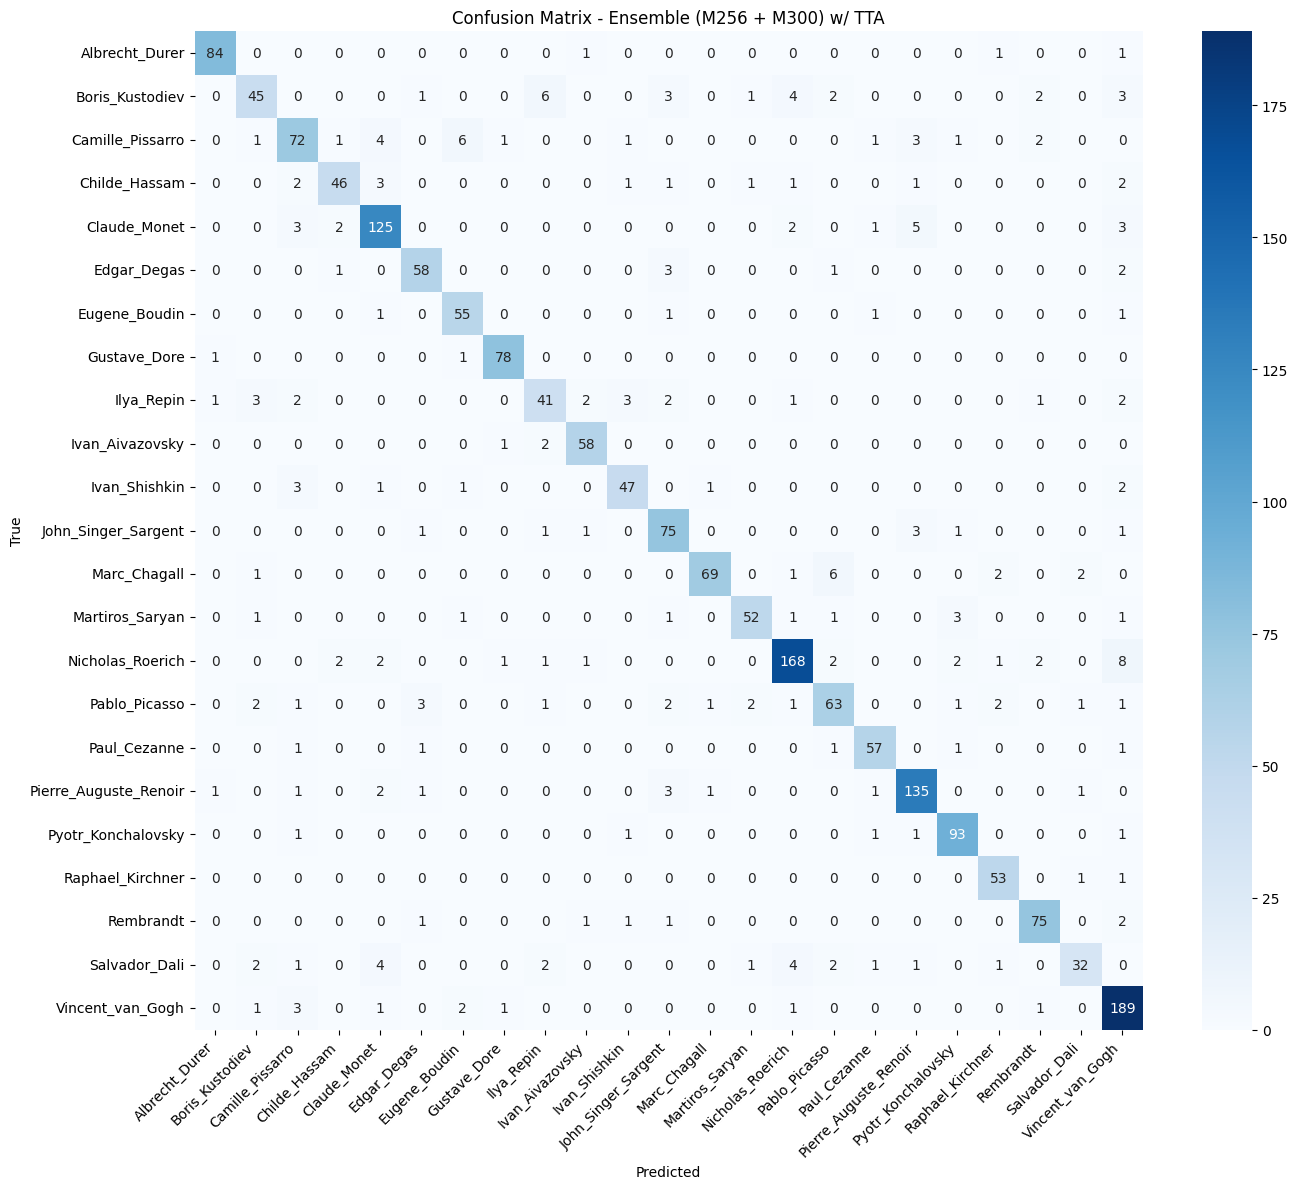

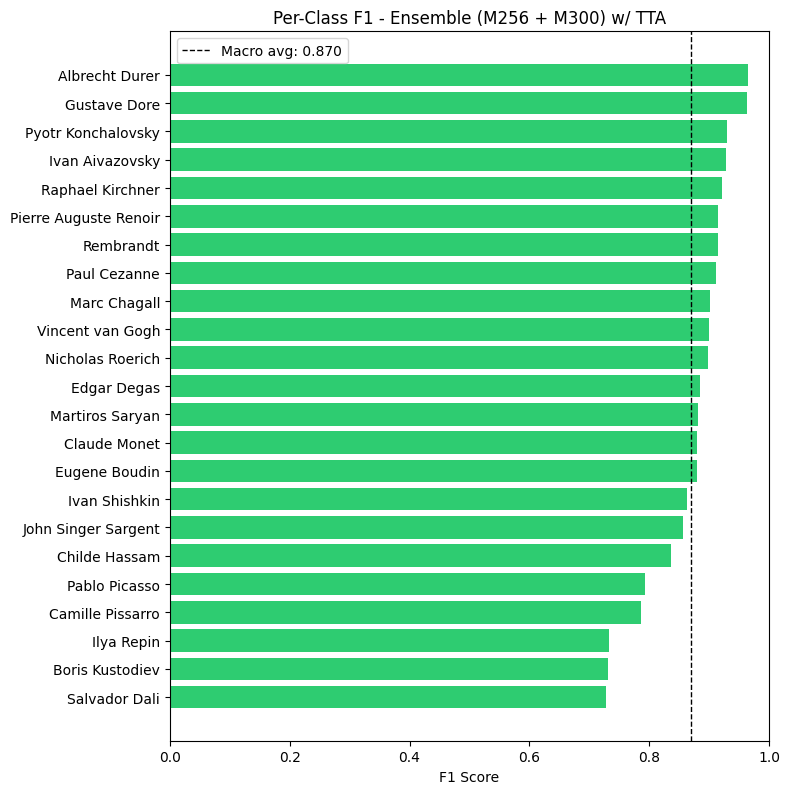

In [4]:
# ── 8. Ensemble with Test-Time Augmentation (TTA) ─────────────────────────────
# This cell performs TTA manually to bypass the bug in utils.py caused by 
# integer labels, while maintaining optimal memory usage for the GTX 1650 - the GPU used to run this cell.

n_augmentations = 10
print(f"--- Starting TTA Ensemble with {n_augmentations} augmentations ---")

# Define a simple augmentation pipeline to be applied during inference
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Initialize accumulators for the probabilities
# We use the existing probability shapes from the non-TTA predictions
probs_tta_256 = np.zeros_like(probs_test_256)
probs_tta_300 = np.zeros_like(probs_test_300)

for i in range(n_augmentations):
    print(f"  Processing Augmentation {i+1}/{n_augmentations}...")
    
    # Map the augmentation to the datasets (training=True forces augmentation at inference)
    aug_ds_256 = test_ds_256.map(lambda x, y: (data_augmentation(x, training=True), y))
    aug_ds_300 = test_ds_300.map(lambda x, y: (data_augmentation(x, training=True), y))
    
    # Predict and accumulate results
    probs_tta_256 += model_256.predict(aug_ds_256, verbose=0)
    probs_tta_300 += model_300.predict(aug_ds_300, verbose=0)

# Compute the mean probabilities across all TTA iterations
probs_tta_256 /= n_augmentations
probs_tta_300 /= n_augmentations

# ── Weighted TTA Fusion ───────────────────────────────────────────────────────
# Apply the optimal weights derived from the previous validation grid search.
print(f"\n--- Finalizing TTA Ensemble (M256 weight: {best_w:.2f}) ---")

ensemble_probs_tta = best_w * probs_tta_256 + (1 - best_w) * probs_tta_300
ensemble_preds_tta = np.argmax(ensemble_probs_tta, axis=1)

# Generate the final classification report and confusion matrix using y_test_true
metrics_ensemble_tta = evaluate_from_predictions(
    y_true=y_test_true, 
    y_pred=ensemble_preds_tta, 
    y_pred_probs=ensemble_probs_tta, 
    class_names=class_names, 
    model_name="Ensemble (M256 + M300) w/ TTA"
)